In [4]:
import os
import time
import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier

import warnings

# OPTUNA
import optuna

In [5]:
# ==========================================
# 1. PREPARACIÓN DE DATOS (POLARS)
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# LightGBM prefiere etiquetas 0 (Ataque) y 1 (Normal)
y_full_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal").then(1).otherwise(0).alias("label")
    ).to_series().to_numpy()
)

y_test_np = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal").then(1).otherwise(0).alias("label")
    ).to_series().to_numpy()
)

X_full_train = df_train.drop(TARGET_COL).to_numpy()
X_test_np = df_test.drop(TARGET_COL).to_numpy()

print(f"✅ Datos listos. Train: {X_full_train.shape[0]} muestras, Test: {X_test_np.shape[0]} muestras.")

✅ Datos listos. Train: 175341 muestras, Test: 82332 muestras.


In [ ]:
# ==========================================
# 2. FASE 1: OPTUNA + 3-FOLD CV (ESTRUCTURA REAL)
# ==========================================

# Convertir -1/1 a 0/1 ANTES de entrar a Optuna
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)


def objective(trial):

    warnings.filterwarnings("ignore", category=UserWarning)
    
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    num_leaves = trial.suggest_int("num_leaves", 15, 255) 
    max_depth = trial.suggest_int("max_depth", 3, 12)    
    
    # Configuración CV (3 Folds) #
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 
    f1_scores = []
    latencies = []

    for train_idx, val_idx in skf.split(X_full_train, y_full_train_01):
        X_train_cv, X_val_cv = X_full_train[train_idx], X_full_train[val_idx]
        y_train_cv, y_val_cv = y_full_train_01[train_idx], y_full_train_01[val_idx]

        model = LGBMClassifier(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=0.1,  
            objective="binary", # Forzamos que sepa que es 0/1
            device_type="gpu",
            n_jobs=-1,          
            random_state=42,
            verbosity=-1        
        )

        model.fit(X_train_cv, y_train_cv)
        model.set_params(device_type="cpu")

        # 1. Medir Eficacia
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))

        # 2. Medir Eficiencia dentro de cada fold
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]

        # Warm-up rápido
        _ = model.predict(X_lat[:500])

        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    avg_lat = float(np.mean(latencies))
    avg_f1 = float(np.mean(f1_scores))
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# Ejecución del estudio
study = optuna.create_study(directions=["maximize", "minimize"], study_name="lgbm_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con LightGBM...")
study.optimize(objective, n_trials=50)

# ==========================================
# 3. EXPORTACIÓN Y VISUALIZACIÓN PARETO
# ==========================================

pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "num_leaves": t.params["num_leaves"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("lgbm_trials_results_cv.csv")

[I 2026-03-23 20:39:12,480] A new study created in memory with name: lgbm_ids_optimization


🚀 Iniciando barrido multiobjetivo con LightGBM...


[I 2026-03-23 20:43:32,385] Trial 0 finished with values: [0.9333456016553738, 0.00042379296384751795] and parameters: {'n_estimators': 150, 'num_leaves': 20, 'max_depth': 12}.
[I 2026-03-23 20:43:42,713] Trial 1 finished with values: [0.9364166983911439, 0.000758289685472846] and parameters: {'n_estimators': 350, 'num_leaves': 240, 'max_depth': 8}.
[I 2026-03-23 20:43:47,874] Trial 2 finished with values: [0.9362916241236552, 0.0001588865276426077] and parameters: {'n_estimators': 100, 'num_leaves': 145, 'max_depth': 12}.
[I 2026-03-23 20:44:03,178] Trial 3 finished with values: [0.9362105109870795, 0.0006422571372240782] and parameters: {'n_estimators': 500, 'num_leaves': 95, 'max_depth': 10}.
[I 2026-03-23 20:44:20,002] Trial 4 finished with values: [0.9359208952527422, 0.0007506398484110832] and parameters: {'n_estimators': 600, 'num_leaves': 86, 'max_depth': 11}.
[I 2026-03-23 20:44:28,055] Trial 5 finished with values: [0.9368669163784439, 0.00039106665179133415] and parameters: 

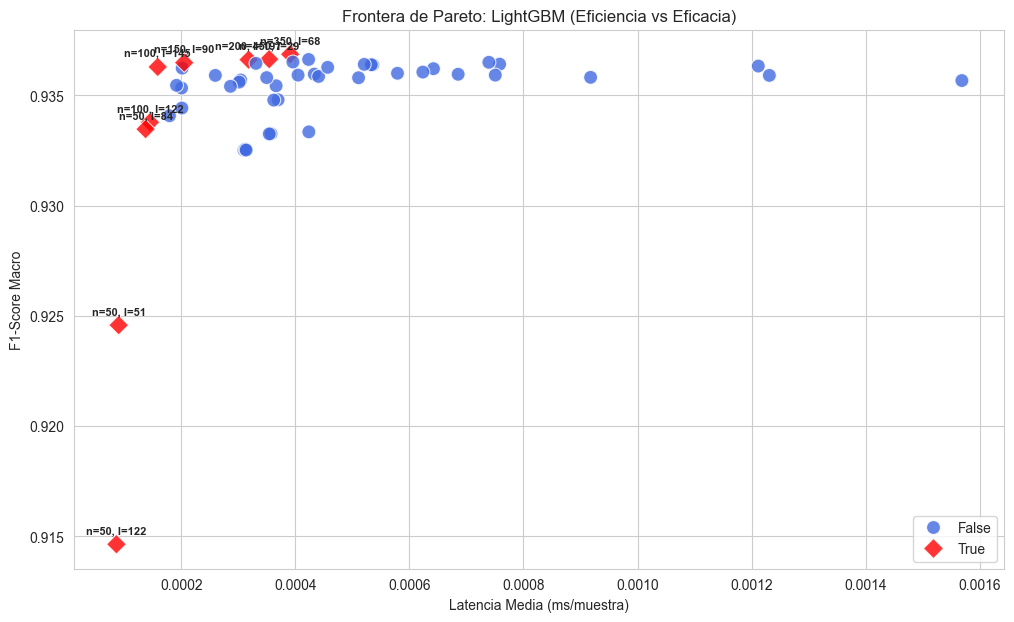

In [7]:
# Gráfico usando NumPy bridge para evitar dependencia de PyArrow/Pandas
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.scatterplot(
    x=df_results["latency_ms"].to_numpy(),
    y=df_results["f1_macro"].to_numpy(),
    hue=df_results["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df_results["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"}, s=100, alpha=0.8
)

# Anotación de puntos Pareto
pareto_points = df_results.filter(pl.col("is_pareto") == True)
for row in pareto_points.iter_rows(named=True):
    plt.text(row["latency_ms"], row["f1_macro"] + 0.0005, 
             f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}", 
             fontsize=8, fontweight='bold', ha='center')

plt.title("Frontera de Pareto: LightGBM (Eficiencia vs Eficacia)")
plt.xlabel("Latencia Media (ms/muestra)")
plt.ylabel("F1-Score Macro")
plt.show()

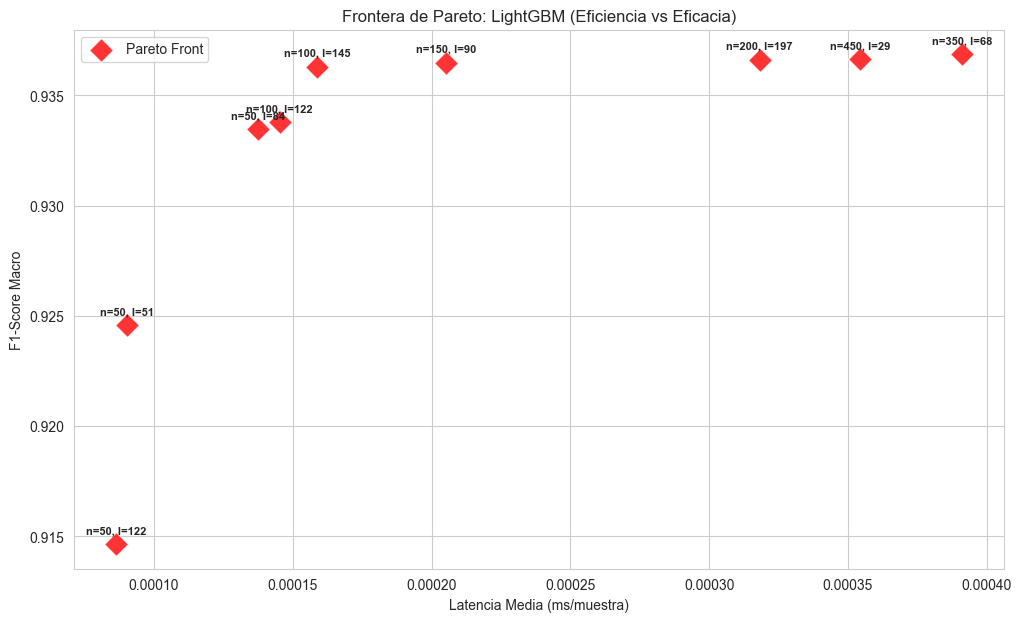

n_estimators,num_leaves,max_depth,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,f64,f64,f64,bool
100,145,12,0.936292,0.0012,0.000159,true
350,68,9,0.936867,0.000646,0.000391,true
450,29,12,0.936643,0.000714,0.000354,true
200,197,11,0.93662,0.000961,0.000318,true
50,122,3,0.91465,0.000703,0.000086,true
150,90,12,0.936485,0.000913,0.000205,true
100,122,7,0.933782,0.000679,0.000145,true
50,51,5,0.924584,0.001589,0.00009,true
50,84,12,0.93347,0.000548,0.000138,true


In [8]:
# Gráfico solo con puntos Pareto
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

pareto_points = df_results.filter(pl.col("is_pareto") == True)

sns.scatterplot(
    x=pareto_points["latency_ms"].to_numpy(),
    y=pareto_points["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=150,
    alpha=0.8,
    label="Pareto Front"
)

# Anotación de puntos Pareto
for row in pareto_points.iter_rows(named=True):
    plt.text(row["latency_ms"], row["f1_macro"] + 0.0005, 
             f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}", 
             fontsize=8, fontweight='bold', ha='center')

plt.title("Frontera de Pareto: LightGBM (Eficiencia vs Eficacia)")
plt.xlabel("Latencia Media (ms/muestra)")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.show()

display(pareto_points)

In [9]:
# ==========================================
# 4. FASE 3: EVALUACIÓN FINAL EN TEST
# ==========================================

# Aquí deberás ajustar estos candidatos con los que veas en ROJO en tu gráfica
candidatos = [
    {"n": 350, "l": 68, "d": 9,  "nombre": "Candidato 1"},
    {"n": 450, "l": 29, "d": 12,  "nombre": "Candidato 2"},
    {"n": 150, "l": 90, "d": 12, "nombre": "Candidato 3"},
    {"n": 100, "l": 145, "d": 12, "nombre": "Candidato 4"},
    {"n": 100, "l": 122, "d": 7, "nombre": "Candidato 5"},
]

resultados_finales = []

print("\n--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---")
for c in candidatos:
    model_final = LGBMClassifier(
        n_estimators=c["n"],
        num_leaves=c["l"],
        max_depth=c["d"],
        learning_rate=0.1, # Coherencia con la Fase 1
        device_type="gpu",
        n_jobs=-1,
        random_state=42,
        verbosity=-1
    )
    
    model_final.fit(X_full_train, y_full_train)
    model_final.set_params(device_type="cpu")
    
    # Medición de latencia real en Test (5 pasadas)
    t_start = time.perf_counter()
    y_test_pred = model_final.predict(X_test_np)
    t_end = time.perf_counter()
    
    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_est": c["n"],
        "leaves": c["l"],
        "depth": c["d"],
        "F1_Test": f1_score(y_test_np, y_test_pred, average="macro"),
        "Acc_Test": accuracy_score(y_test_np, y_test_pred),
        "Latencia_ms": ((t_end - t_start) / len(X_test_np)) * 1000
    })

df_final = pl.DataFrame(resultados_finales)
print("\n", df_final)


--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---

 shape: (5, 7)
┌─────────────┬───────┬────────┬───────┬──────────┬──────────┬─────────────┐
│ Perfil      ┆ n_est ┆ leaves ┆ depth ┆ F1_Test  ┆ Acc_Test ┆ Latencia_ms │
│ ---         ┆ ---   ┆ ---    ┆ ---   ┆ ---      ┆ ---      ┆ ---         │
│ str         ┆ i64   ┆ i64    ┆ i64   ┆ f64      ┆ f64      ┆ f64         │
╞═════════════╪═══════╪════════╪═══════╪══════════╪══════════╪═════════════╡
│ Candidato 1 ┆ 350   ┆ 68     ┆ 9     ┆ 0.861467 ┆ 0.867354 ┆ 0.000371    │
│ Candidato 2 ┆ 450   ┆ 29     ┆ 12    ┆ 0.860196 ┆ 0.86631  ┆ 0.00036     │
│ Candidato 3 ┆ 150   ┆ 90     ┆ 12    ┆ 0.860457 ┆ 0.866552 ┆ 0.0002      │
│ Candidato 4 ┆ 100   ┆ 145    ┆ 12    ┆ 0.859564 ┆ 0.865775 ┆ 0.000159    │
│ Candidato 5 ┆ 100   ┆ 122    ┆ 7     ┆ 0.852491 ┆ 0.859654 ┆ 0.000137    │
└─────────────┴───────┴────────┴───────┴──────────┴──────────┴─────────────┘
